# Single-nucleus RNA-seq beetle (*Nicrophorus vespilloides*): cell type annotation

To annotate cell-types, we combined two complementary approaches: (i) identification of cluster-specific **marker genes** and literature search (functional evidence in insects / fruit fly larvae) and (ii) direct **comparison to fruit fly adult cell types** using annotated single-cell data from the [**FLY CELL ATLAS**](https://flycellatlas.org/) (no established reference nomenclature / cell annotation for larvae).

# Table of Contents
1. [Final cell cluster annotation](#part1)
1. [All marker genes](#part2)
2. [Selected markers](#part3)
3. [Comparison with FLY CELL ATLAS](#part4)
4. [QC plots](#part5)

In [2]:
library(Seurat) #‘5.4.0’
library(tidyverse)
library(dittoSeq)

In [3]:
objnames <- LoadSeuratRds("tmp_objects/seurat_combinedobj_qclus_integrated.rds")

In [4]:
objnames

An object of class Seurat 
25690 features across 16201 samples within 3 assays 
Active assay: integrated (3000 features, 3000 variable features)
 2 layers present: data, scale.data
 2 other assays present: RNA, SCT
 2 dimensional reductions calculated: pca.integrated, umap.integrated

In [5]:
DefaultAssay(objnames) <- "SCT"

## 1. Final cell cluster annotation <a name="part1"></a>

We rename clusters here to ease direct inspection of markers and annotations in the plots generated below, although this was initially obviously done after section 4.

### Broad labels

In [6]:
Idents(objnames) <- objnames@meta.data$seurat_clusters

#Broad annotation labels
objnames <- RenameIdents(object = objnames,
  "0" = "muscle_0", "1" = "epithelia_1", "2" = "epithelia_2", "3" = 'epithelia_3', "4" = "epithelia_4",
  "5" = "epithelia_5", "6"="epithelia_6", "7"="epithelia_7", "8"="NB-glia_8",
  "9" = "epithelia_9", "10" = "fat.body_10", "11"="mature.neuron_11", "12"="epithelia_12",
  "13"="epithelia_13", "14"="NB-glia_14","15"="trachea_15", "16"="hemocyte_16",
  "17"="NB-glia_17", "18"="NB-glia_18", "19"="muscle_19",
  "20"="mature.neuron_20", "21"="fibroblast_21", "22"="gland_22")

Idents(objnames) <- factor(objnames@active.ident, sort(levels(objnames@active.ident)))
objnames@meta.data$broad_labels <- Idents(objnames)

In [7]:
colbroad <- c("epithelia_1" = 'goldenrod2', "epithelia_12" = 'goldenrod2', "muscle_0" = 'hotpink2',
               "muscle_19"='hotpink2',
               "epithelia_2" = "goldenrod2", "epithelia_4"="goldenrod2", 
               "epithelia_3"='goldenrod2', "epithelia_7"='goldenrod2',
               "epithelia_13"='goldenrod2', "gland_22"='purple',
               "fibroblast_21"='yellow', "epithelia_5"='goldenrod2',
               "NB-glia_14" = 'skyblue1', "NB-glia_17"='skyblue1',
               "NB-glia_8"='skyblue1', "NB-glia_18"='skyblue1',
               "mature.neuron_11"='steelblue', "mature.neuron_20"="steelblue","fat.body_10"='gray50',
               "epithelia_9"='goldenrod2', "hemocyte_16"='#8e6100', "epithelia_6"='goldenrod2', "trachea_15"='red')

my_order <- rev(c("muscle_0", "muscle_19", "gland_22", "hemocyte_16", "mature.neuron_11", "mature.neuron_20",
                  "NB-glia_17", "NB-glia_8", "NB-glia_18", "NB-glia_14" ,
              "trachea_15", "fat.body_10", "fibroblast_21",'epithelia_9', "epithelia_1", "epithelia_3", "epithelia_4", "epithelia_5",
                  "epithelia_7", "epithelia_13", "epithelia_2" ,  "epithelia_12","epithelia_6"
              ))

levels(objnames) <- my_order

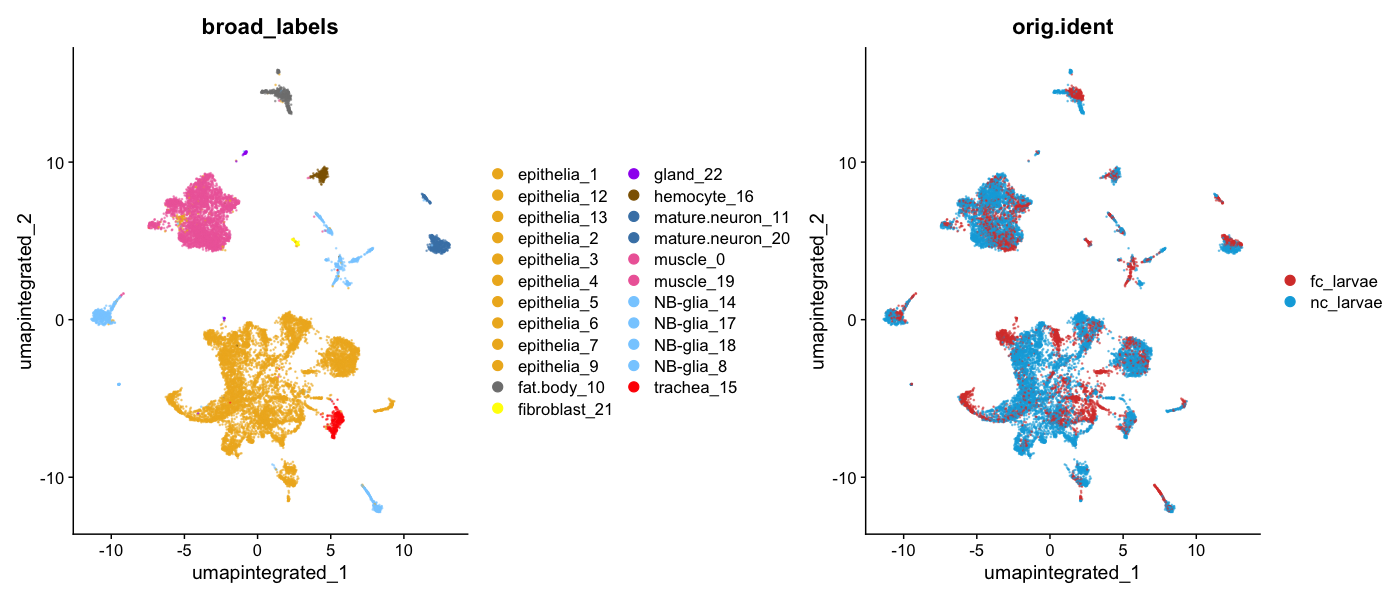

In [8]:
options(repr.plot.width = 14, repr.plot.height = 6, repr.plot.res = 100)
# pdf(file = "broadUMAP.pdf", width = 14, height = 6) # defaults to 7 x 7 inches

DimPlot(
  objnames,
  reduction = "umap.integrated",
  group.by = c("broad_labels"), cols=colbroad,
  shuffle = TRUE, alpha=0.5
) + DimPlot(
  objnames,
  reduction = "umap.integrated",
  group.by = c("orig.ident"),
  shuffle = TRUE, alpha=0.5,cols=c("#d84036ff", "#00abdeff")
)
# dev.off()

### Specific labels

In [9]:
Idents(objnames) <- objnames@meta.data$seurat_clusters

maplabel <- c("0" = "muscle.rbm24_0", "1" = "epithelia.cuticle.cp.other_1", "2" = "epithelia.cuticle.Osi16_2", "3" = 'epithelia.cuticle.cp.soft_3',
                         "4" = "epithelia.cuticle.Osi17_4",
  "5" = "epithelia.tendon_5", "6"="epithelia.cuticle.Osi18_6", "7"="epithelia.cuticle.cp.rigid_7", "8"="glia1_8",
  "9" = "epithelia.olfactory.support_9", "10" = "fat.body_10", "11"="neuron.cholinergic_11", "12"="epithelia.cuticle.Osi14_12",
  "13"="epithelia.cuticle.biosynthesis_13", "14"="neuroglioblast.ol_14","15"="trachea_15", "16"="hemocyte_16",
  "17"="neuroglioblast.castor_17", "18"="glia2_18", "19"="muscle.tup_19",
  "20"="neuron.chol.ciliated_20", "21"="secretory-ECM_21", "22"="gland.corpora-allata_22")

objnames <- RenameIdents(object = objnames, maplabel)
  
my_order <- c("muscle.rbm24_0", "muscle.tup_19", "gland.corpora-allata_22","hemocyte_16","fat.body_10", "secretory-ECM_21","neuron.cholinergic_11", "neuron.chol.ciliated_20",
              "neuroglioblast.castor_17", "glia1_8", "glia2_18", "neuroglioblast.ol_14",
              "trachea_15","epithelia.tendon_5", "epithelia.olfactory.support_9", "epithelia.cuticle.cp.other_1", 
              'epithelia.cuticle.cp.soft_3',"epithelia.cuticle.Osi17_4",
               "epithelia.cuticle.Osi14_12", "epithelia.cuticle.Osi18_6","epithelia.cuticle.Osi16_2",
              "epithelia.cuticle.cp.rigid_7", "epithelia.cuticle.biosynthesis_13")

my_colors_spec <- c("epithelia.cuticle.cp.other_1" = 'goldenrod2', "epithelia.cuticle.Osi14_12" = '#fdff9dff',
               "muscle.rbm24_0" = '#ffc0cbcc',"muscle.tup_19"='#ee6aa7cc',
               "epithelia.cuticle.Osi16_2" = "#fff8dccc", "epithelia.cuticle.Osi17_4"="#ffdd94",
               "epithelia.cuticle.cp.soft_3"='#ffe6b0cc', "epithelia.cuticle.cp.rigid_7"='#c57f00cc',
               "epithelia.cuticle.biosynthesis_13"='#ffc078', "gland.corpora-allata_22"='purple',
               "secretory-ECM_21"='#2cae50be', "epithelia.tendon_5"='#ff7f50cc',
               "neuroglioblast.ol_14" = '#1ed9f8f4', "neuroglioblast.castor_17"='#15affeff',
               "glia1_8"='lightblue2', "glia2_18"='#63b8ffcc',
               "neuron.cholinergic_11"='#000080cc', "neuron.chol.ciliated_20"="#4682b4cc","fat.body_10"='#7f7f7fff',
               "epithelia.olfactory.support_9"='darkorange2', "hemocyte_16"='#8e6100cc', "epithelia.cuticle.Osi18_6"='bisque3',
               "trachea_15"='#ee0000cc')

levels(objnames) <- my_order
objnames@meta.data$seurat_clusters_labels <- Idents(objnames)


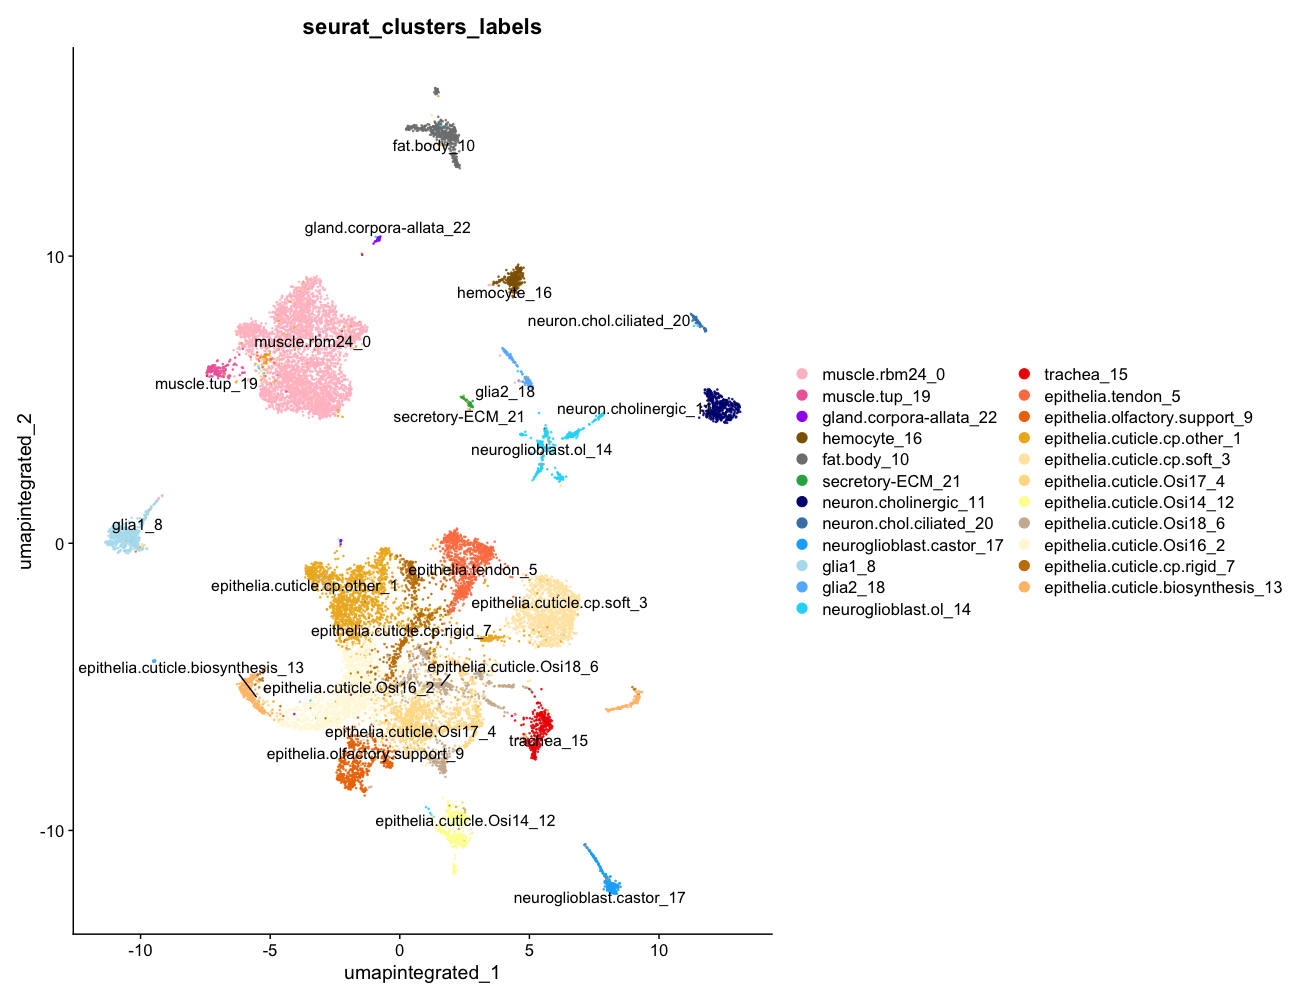

In [10]:
options(repr.plot.width = 13, repr.plot.height = 10, repr.plot.res = 100)

# pdf(file = "specUMAPTest.pdf", width = 13, height = 10) # defaults to 7 x 7 inches

p = DimPlot(
  objnames,
  reduction = "umap.integrated",
  group.by ="seurat_clusters_labels",
  shuffle = TRUE, label=TRUE, repel = T,  cols = my_colors_spec, alpha=0.8
)
p
# dev.off()
# p

## 2. All marker genes <a name="part2"></a>

Get significant markers for each cluster using Wilcoxon test as implemented in Seurat

In [11]:
objnames <- PrepSCTFindMarkers(objnames, assay = "SCT")

MarkersSCT <- FindAllMarkers(objnames, only.pos = TRUE, min.pct = 0.05, logfc.threshold = 0.25, assay = "SCT")

Found 2 SCT models. Recorrecting SCT counts using minimum median counts: 634

Calculating cluster muscle.rbm24_0

For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster muscle.tup_19

Calculating cluster gland.corpora-allata_22

Calculating cluster hemocyte_16

Calculating cluster fat.body_10

Calculating cluster secretory-ECM_21

Calculating cluster neuron.cholinergic_11

Calculating cluster neuron.chol.ciliated_20

Calculating cluster neuroglioblast.castor_17

Calculating cluster glia1_8

Calculating cluster glia2_18

Calculating cluster neuroglioblast.

Filter and sort and then save to file

In [12]:
MarkersSCT.all <- MarkersSCT %>%
filter(p_val_adj < 0.05, avg_log2FC > 1) %>%
  mutate(delta.pct = pct.1 - pct.2)  %>%
  arrange(cluster, desc(delta.pct), p_val)%>%
  select(gene, cluster, p_val, p_val_adj, everything())

write.table(MarkersSCT.all, 
            file = "beetle_seurat_markers_all.tsv", 
            sep = "\t", 
            row.names = FALSE, 
            quote = FALSE)

## 3. Selected marker genes <a name="part3"></a>

#### Broad annotation

We inspect expression of well-established marker genes in insect, commonly used to identify broad cell types.

Gene names below are uniprot names and can be converted using the gene master table `../../genome_assembly/genome_files/genes/gene_models_allinfos_for_snRNAseq.tsv` to obtain gene names used in the manuscript and figures (see columns `gene name` for gene names used in the manuscript and its figure and `OLD_gene_name` for gene names stored in the seurat object). This applies to all Dotplots, heatmaps and gene-based plots.

In [13]:
broadM <- c('MYSA', 'MEF2', 'JHAMT-1', 'HMCT', 'PPN',  'ELAV3', 'SY65', 'SCNA','PNT' , 'GLNA2-1', 'RX1', 'TRH',  'APLP-3','APLP-2', 'CO1A2', 
            'COBA1', 'ELF1', 'HR38')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


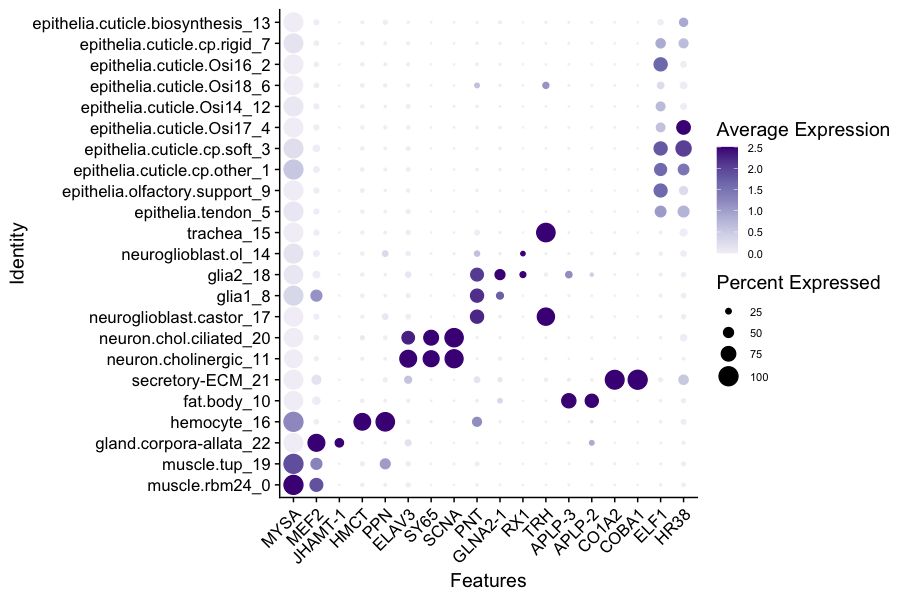

In [14]:
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 100)

# pdf(file = "Broad-M-Final.pdf", width = 7, height = 6) # defaults to 7 x 7 inches

p <- DotPlot(objnames, features = broadM, assay='SCT', scale=TRUE, scale.min = 1, col.min=0, col.max=2.5) + RotatedAxis()+
  scale_color_distiller(palette='Purples', direction = 0) + theme(
    axis.text.x = element_text(size = 12), # Gene labels
    axis.text.y = element_text(size = 12), # Cluster labels
    legend.text = element_text(size = 8),  # Legend font
  )
p
# dev.off()
# p

### Specific annotation

We inspect below expression of top markers for each cluster, focusing on genes with a known, experimentally-validated function in insects.

In [15]:
ca = c('FPPS','AL3A1', "C15A1")
hm = c('LAMA','GAT5A','PNR-1','PCE-1')
chol = c('CAC1A-2','VACHT','ACHA7-2','ADA12-2', 'NVE00956') #shared before ACHA, cac = general larva neuron 
cil = c('TRPC4-2','HAM-2','CFA36') #nompC = sensory neuron larva
trh = c('SPTN5','LSAMP','MMP20')
fat = c('CO4A2', 'CO4A5','PCY2','LSD1') #fat body
torm = c('NVE05577','NVE05582','NVE05573','DLL','SP9','AHR')
td = c('EGR3','SMTL1','SPT13')
cas = c('CAUP','PTN9','CASZ1')
nbgli = c('NR3AA','ATPB2-2') #glia
nc = c('NVE12306', 'PATH-1', 'CYTSA')
ol = c('NVE08804','NVE08805','RGS')
mu = c('ZASP-2', 'RBM24', 'FGF20')
m2 = c('ATS9', 'ISL1')
fb = c('SRPX2','COMP','SPRC')


o14 = rev(c('OACYL','KNRL','PIPE','NVE13024','MYO7A-1')) 
o18 = c('NVE04783','MYO15', 'NVE13027')
cpo = c('NVE08940','NVE13056','NVE12292') 
o17 = c('NVE12263', 'NVE13026','NVE07814','NVE09934')

cb = rev(c('NVE03838','PERO-1','CHIT1-1','CHS2-1'))
o16 = c('NVE13015', 'NVE13025')
cps = c('CU12-23','CU17-2','CU30-1')
cpr = c('CU19-8','NVE02891')
cuti = c(cpo,  cps, o17, o14, o18, o16, cpr, cb) 

f <- rev(c(mu, m2, ca, hm, fat, fb, chol, cil, cas, nc, nbgli, ol, trh, td, torm, cuti))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


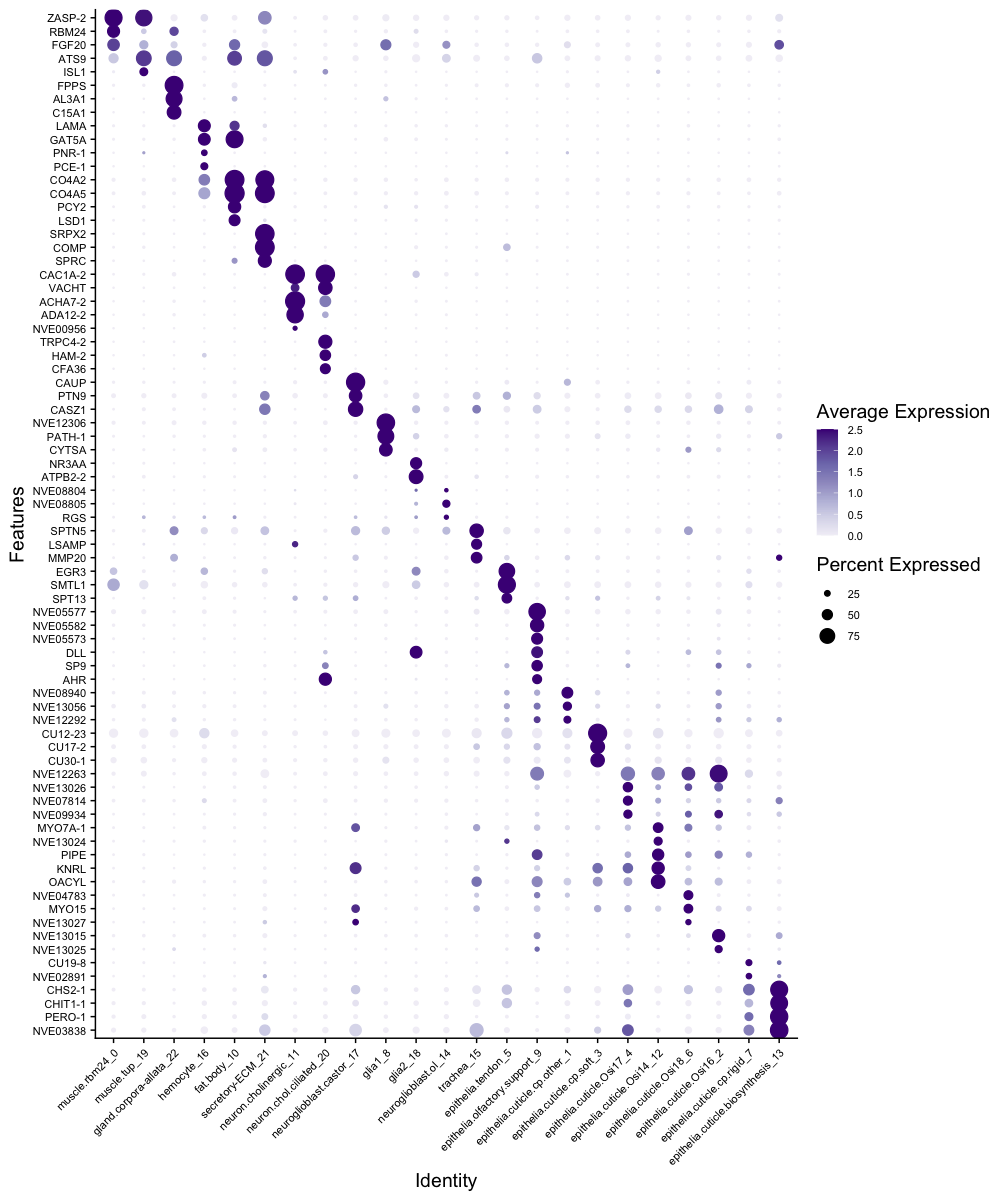

In [16]:
options(repr.plot.width = 10, repr.plot.height = 12, repr.plot.res = 100)
# pdf(file = "specMarkers.pdf", width = 10, height = 12) # defaults to 7 x 7 inches

p<- DotPlot(objnames, features = f, assay='SCT', scale=TRUE, scale.min = 1, col.min=0, col.max=2.5) + RotatedAxis() + coord_flip() +
  scale_color_distiller(palette='Purples', direction = 0) + theme(
    axis.text.x = element_text(size = 8), # Gene labels
    axis.text.y = element_text(size = 8), # Cluster labels
    legend.text = element_text(size = 8),  # Legend font
  )
p
# dev.off()
# p

### Architectural cuticle proteins

We used **[CuticleDB](http://bioinformatics2.biol.uoa.gr/cuticleDB/)** to directly classify all proteins with a PFAM Chitin_binding domain into soft (RR1 class) and rigid (RR2 class) cuticle proteins.

In [17]:
cpRR2 <-c('NVE01415','NVE01417','NVE01418','CU19-1','CU19-2','CU20-1','CU19-3','CU19-4','CU19-5','CU19-6','CU19-7',
          'NVE02855','CU19-8','CU19-9','NVE02858','CU19-10','CU19-11','NVE02863','NVE02864','NVE02866','NVE02867',
          'CU19-12','CU19-13','NVE02870','CU19-14','NVE02872','CUA3A-1','CU19-15','CU19-16','CUA3A-2','NVE02890',
          'NVE02891','NVE02894','CU19-18','CU08','CU19-19','CU19-20','CU19-21','CU109','CU20-2','CUO8','CU19-22',
          'CUA3A-3','CU07-1','CU19-23','NVE06852','NVE07058','NVE07059','NVE07594','RESIL-1','RESIL-2','CU198','CU07-2',
          'CU19-24','CU22','CU19-25','CUA3A-4','CUA3A-5','CUA3A-6','CUA3A-7','CUA3A-8','CUA3A-9','CUA3A-10','CUA3A-11',
          'CUA3A-12','CU19-26','CUA3A-14','CUO6')

pct_info <- rowSums(GetAssayData(objnames, layer = "counts") > 0) / ncol(objnames)
genes_keep <- names(pct_info[pct_info >= 0.01])

cpRR2 <- sort(intersect(cpRR2, genes_keep))

In [18]:
cpRR1 <- c('NVE00958','CU12-1','LCP51','CU12-2','CU12-3','CU12-4','CU12-5','CU12-6','CU12-7','CU12-8','CU12-9',
           'CU12-10', 'CU12-11','NVE01773','NVE01774','NVE01775','NVE01776','CU12-12','CU15-1','NVE01779','LCP81-1',
           'CU15-2','CU15-3','CU12-13','CU12-14','CU12-15','CU12-16','CU12-17','NVE01788','CU12-18','CU12-19',
           'CU12-20','CU12-21','CU12-22','CU12-23','CU12-24','NVE01877','CUD8-1','CUD8-2','CUD8-3','CUD8-4',
           'NVE01882','CUD8-5','NVE01884','CUD8-6','NVE01886','CUD2-1','CUD2-2','CUD2-3','CUD2-4','CUD2-5','CUD2-6',
           'CUD2-7','CUD2-8','CUD2-9','CUD8-7','CUD2-10','CUD2-11','CUD2-12','CUD1','CU30-1','CU30-2','CU30-3','CU30-4',
           'NVE01908','CUD8-8','CUD8-9','CUD8-10','CUD8-11','CUD8-12','CU17-1','CU17-2','CUD8-13','CUD4-1','CUD4-2',
           'CUD2-13','CUD4-3','CUD4-4','CUD4-5','CUD4-6','CUD4-7','CUD4-8','CUD2-14','CUD8-14','NVE01936','CUD5','CU16-1',
           'CU12-25','CU16-2','LCP81-2','CUD8-15','CU12-26','CUD3','CUD2-15','CUD2-16','NVE02478','NVE02742','CUD2-17',
           'CU36-1','CU17-3','CUD8-16','CU17-4','CU17-5','CUD8-17','CUD8-18','CU12-27','NVE10281','CUD9','CU15-4','CU15-5',
           'CUD2-18','NVE11806','CU36-2','CU36-3','CU24','NVE12293')

pct_info <- rowSums(GetAssayData(objnames, layer = "counts") > 0) / ncol(objnames)
genes_keep <- names(pct_info[pct_info >= 0.01])

cpRR1 <- sort(intersect(cpRR1, genes_keep))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


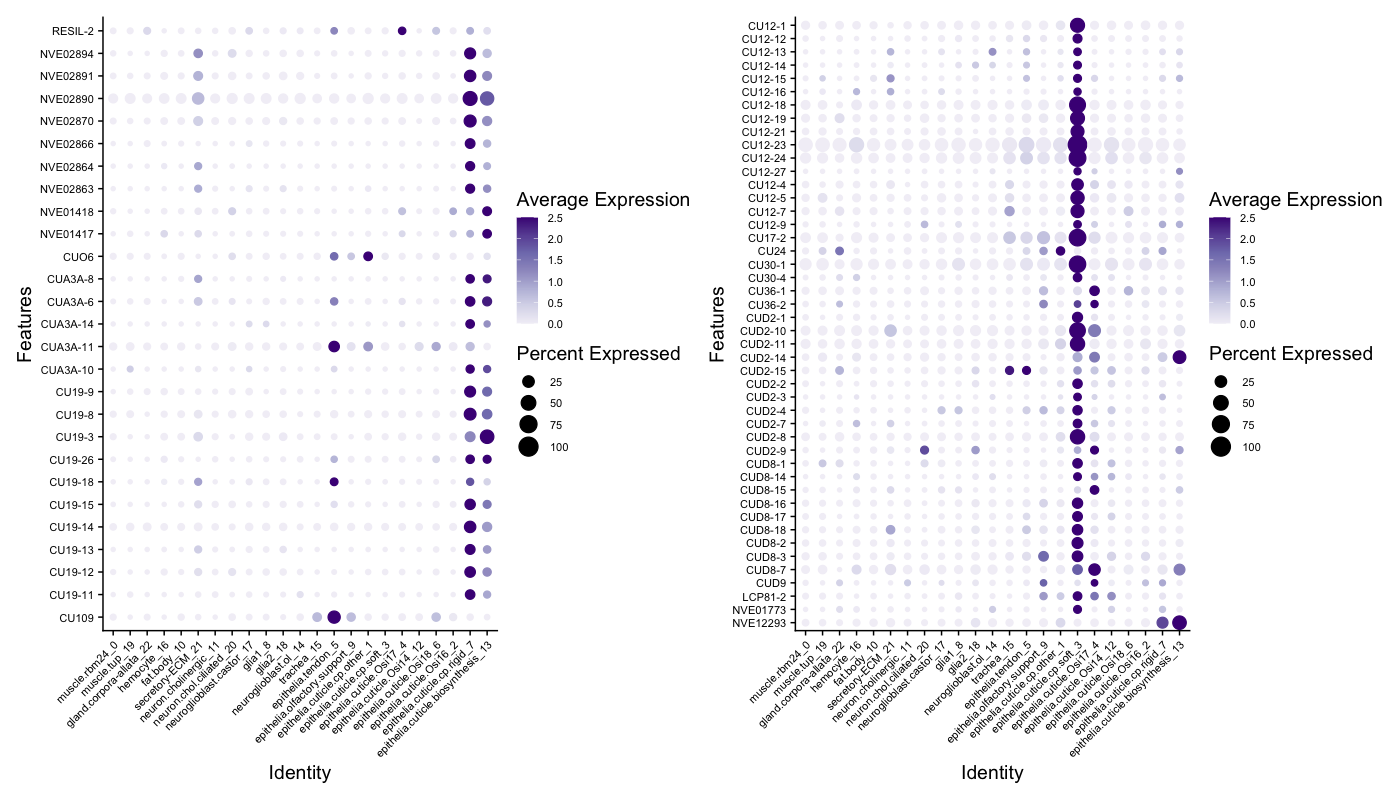

In [19]:

options(repr.plot.width = 14, repr.plot.height = 8, repr.plot.res = 100)
# pdf(file = "cp.soft.rigid.pdf", width = 12, height = 6) # defaults to 7 x 7 inches

p <- DotPlot(objnames, features = cpRR2, assay='SCT', scale=TRUE, scale.min = 1, col.min=0, col.max=2.5) + RotatedAxis() + coord_flip() +
  scale_color_distiller(palette='Purples', direction = 0) + theme(
    axis.text.x = element_text(size = 8), # Gene labels
    axis.text.y = element_text(size = 8), # Cluster labels
    legend.text = element_text(size = 8),  # Legend font
  ) + scale_size(limits = c(1, 100)) +
DotPlot(objnames, features = rev(cpRR1), assay='SCT', scale=TRUE, scale.min = 1, col.min=0, col.max=2.5) + RotatedAxis() + coord_flip() +
  scale_color_distiller(palette='Purples', direction = 0) + theme(
    axis.text.x = element_text(size = 8), # Gene labels
    axis.text.y = element_text(size = 8), # Cluster labels
    legend.text = element_text(size = 8),  # Legend font
  ) + scale_size(limits = c(1, 100))
p
# dev.off()
# p

## 4. Comparison to FLY CELL ATLAS <a name="part5"></a>

We used **[Pesci](https://github.com/eparey/pesci)** our efficient implementation of the ICC algorithm applied to the cross-species comparisons of single-cell expression data (first introduced by [Najle et al.](https://doi.org/10.1016/j.cell.2023.08.027)) to directly compare cell atlases. 

Gene families comprising genes of the burying beetle and drosophila among with other insect and non-insect metazoa were first constructed using [**Broccoli**](https://github.com/rderelle/Broccoli) to obtain a list of homologous genes.

Comparison with adult head datasets broad and specific cell types were performed using Pesci as followed:

- For broad:
```
pesci --matrix1 Nvesp_sparse_matrix/ --matrix2 FlyCellAtlas_adult_antennae_sparse.h5ad FlyCellAtlas_adult_head_sparse.h5ad FlyCellAtlas_adult_proboscis_sparse.h5ad FlyCellAtlas_adult_trachea_sparse.h5ad --clusters1 Nvesp_cell_clusters.tsv --clusters2 'broad_annotation' -g Nvesp_Dmel_brocc.tsv -sp1 Beetle_head_larvae -sp2 FruitFly_adult_broad --force --cores 10 --filter_out 'unknown,artefact,germline,female' -o output_pesci_v2 --reorder Clust
```

- For specific (after retaining fruit fly cluster that are in top 3 match of any beetle cluster):
```
pesci --matrix1 Nvesp_sparse_matrix/ --matrix2 FlyCellAtlas_adult_antennae_sparse.ok.h5ad FlyCellAtlas_adult_head_sparse.ok.h5ad FlyCellAtlas_adult_proboscis_sparse.ok.h5ad FlyCellAtlas_adult_trachea_sparse.ok.h5ad --clusters1 Nvesp_cell_clusters.tsv --clusters2 'annotation' -g Nvesp_Dmel_brocc.tsv -sp1 Beetle_head_larvae -sp2 FruitFly_adult_spec_filt --force --cores 10 --filter_out 'unknown,artefact,germline,female' -o output_pesci_v2 --reorder Clust
```


![fig](expression_data/single-nucleus/final/flyatlas.png)

In [12]:
#SaveSeuratRds(objnames, file = "Nicves_beetle_final_seurat_obj.rds")

## 5. QC plots <a name="part5"></a>

In [20]:
objnames <- LoadSeuratRds("Nicves_beetle_final_seurat_obj.rds")

In [21]:
qclus_nc <- read.table('qclus/NC_qclus_metrics_all.tsv', 
                       sep='\t', header = TRUE, row.names=1)
qclus_nc <- subset(qclus_nc, qclus=='passed')
rownames(qclus_nc) <- paste('nc_', rownames(qclus_nc), '-1', sep='')

qclus_fc <- read.table('qclus/FC_qclus_metrics_all.tsv', 
                       sep='\t', header = TRUE, row.names=1)
rownames(qclus_fc) <- paste('fc_', rownames(qclus_fc), '-1', sep='')
qclus_fc <- subset(qclus_fc, qclus=='passed')
qclus <- bind_rows(qclus_fc, qclus_nc)
qclus <- qclus[rownames(objnames@meta.data),]
objnames <- AddMetaData(object = objnames, metadata = c(qclus["fraction_unspliced"], qclus["pct_counts_MT"]))

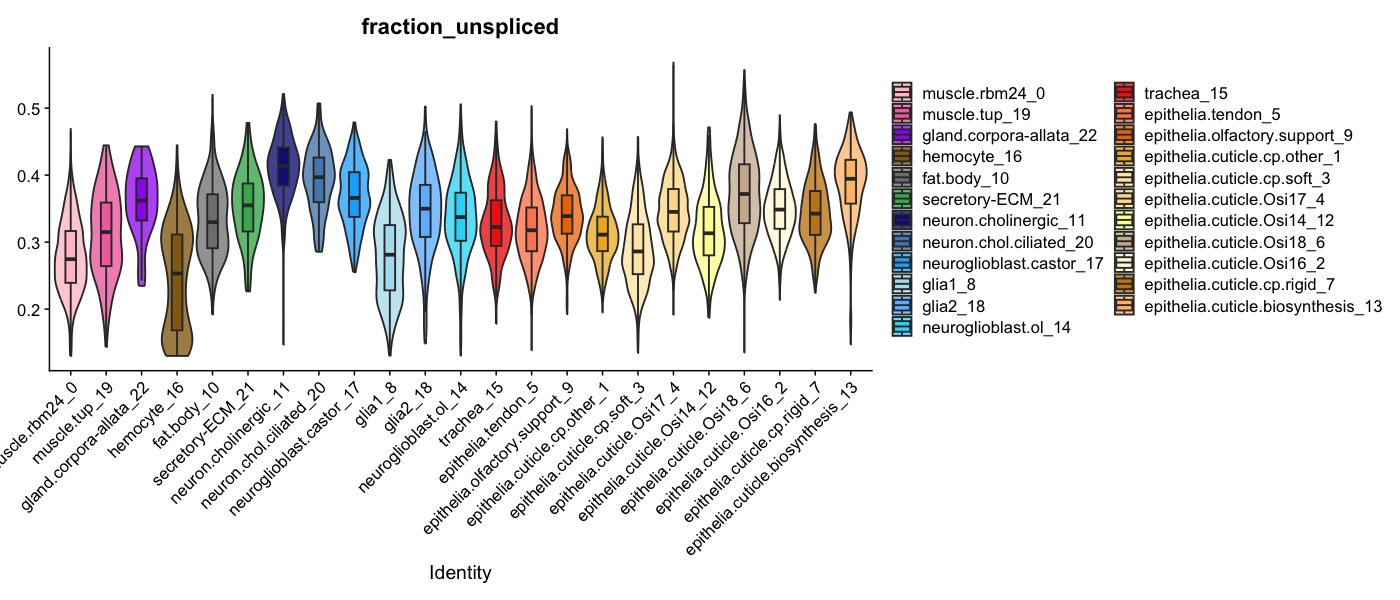

In [22]:
options(repr.plot.width = 14, repr.plot.height = 6, repr.plot.res = 100)
# pdf(file = "QC_unspliced.pdf", width = 14, height = 6) # defaults to 7 x 7 inches

p = VlnPlot(
  object = objnames,
  features = "fraction_unspliced",
    cols=my_colors_spec[my_order],
  # group.by = active.ident,
  pt.size = 0
)  + geom_boxplot(outlier.shape = NA, width = 0.3)
p$layers[[1]]$aes_params$alpha <- 0.75
p
# dev.off()
# p

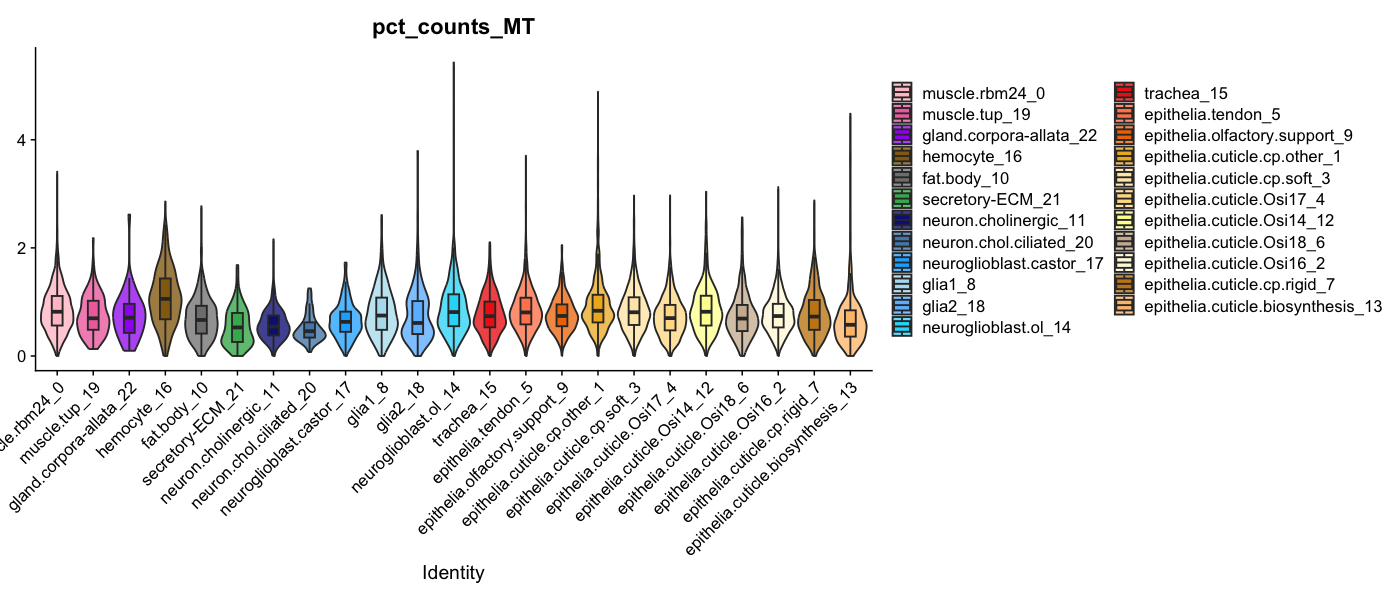

In [23]:
options(repr.plot.width = 14, repr.plot.height = 6, repr.plot.res = 100)
# pdf(file = "QC_MT.pdf", width = 14, height = 6) # defaults to 7 x 7 inches

p = VlnPlot(
  object = objnames,
  features = "pct_counts_MT",
    cols=my_colors_spec[my_order],
  # group.by = active.ident,
  pt.size = 0
) + geom_boxplot(outlier.shape = NA, width = 0.3)
p$layers[[1]]$aes_params$alpha <- 0.75
p
# dev.off()
# p

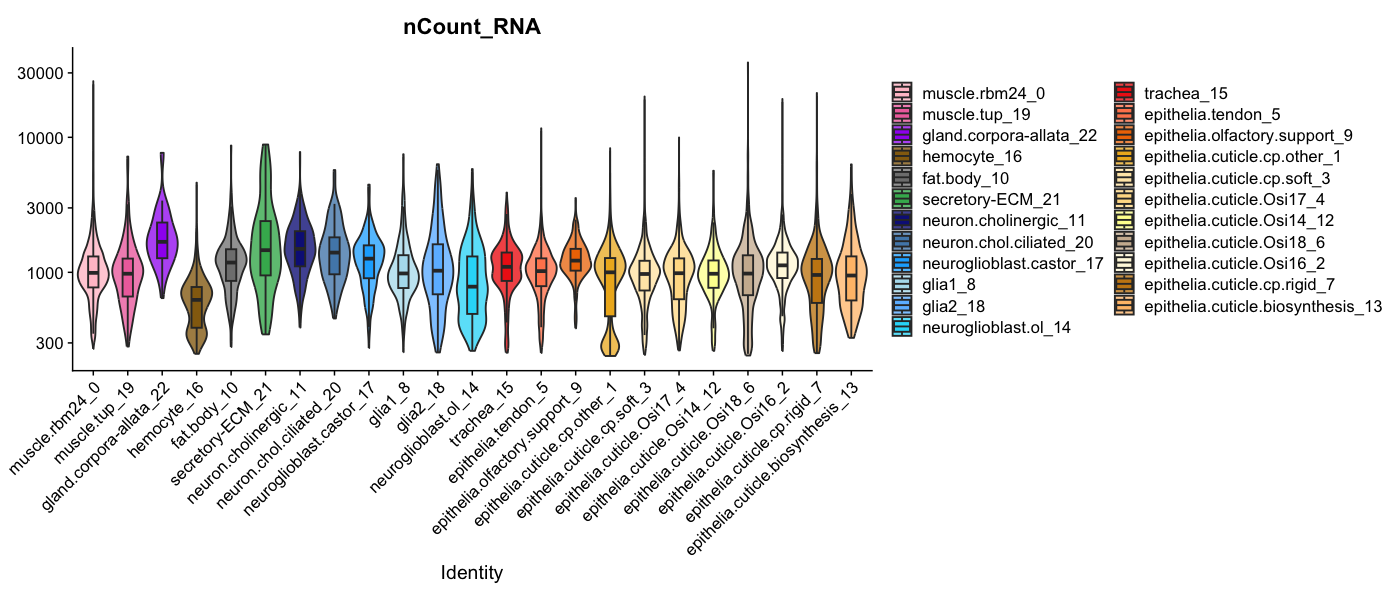

In [24]:
options(repr.plot.width = 14, repr.plot.height = 6, repr.plot.res = 100)
# pdf(file = "QC_nUMI.pdf", width = 14, height = 6) # defaults to 7 x 7 inches

p = VlnPlot(
  object = objnames,
  features = "nCount_RNA",
    cols=my_colors_spec[my_order],
 log = TRUE, alpha=0.1,
  # group.by = active.ident,
  pt.size = 0
)+ geom_boxplot(outlier.shape = NA, width = 0.3)
p$layers[[1]]$aes_params$alpha <- 0.75
p
# dev.off()
# p

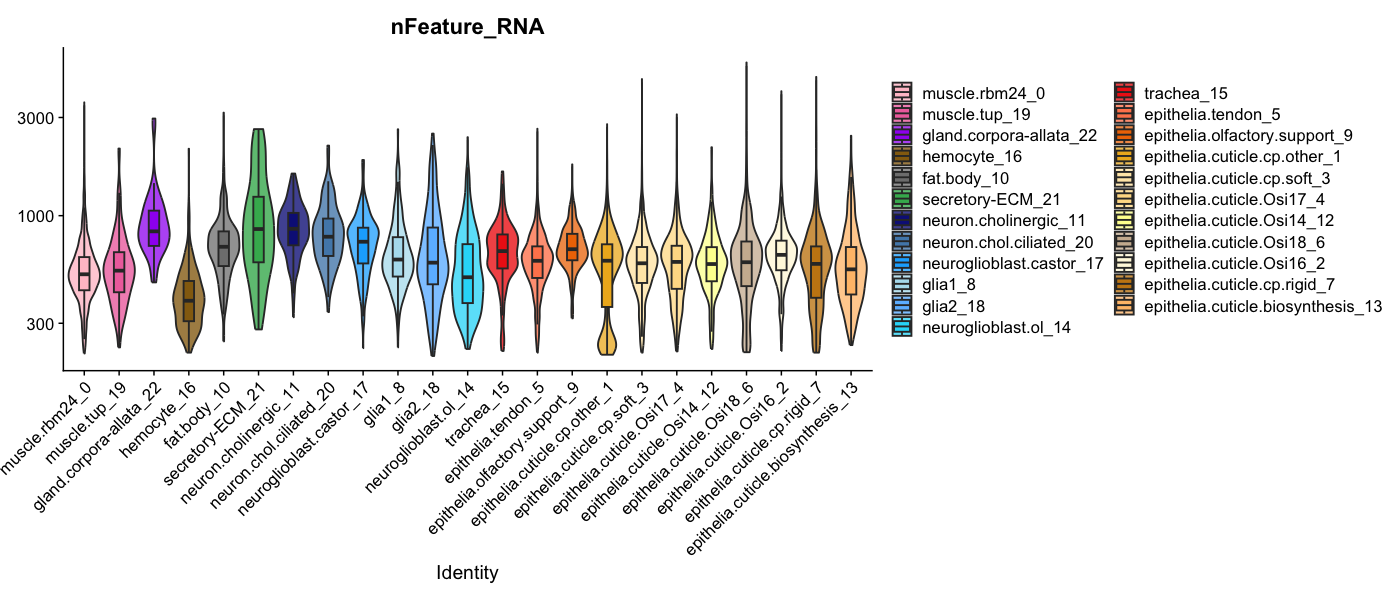

In [25]:
options(repr.plot.width = 14, repr.plot.height = 6, repr.plot.res = 100)
# pdf(file = "QC_genes.pdf", width = 14, height = 6) # defaults to 7 x 7 inches

p=VlnPlot(
  object = objnames,
  features = "nFeature_RNA",
    cols=my_colors_spec[my_order],
  # group.by = active.ident,
  pt.size = 0,
    log=T,
)+ geom_boxplot(outlier.shape = NA, width = 0.3)
p$layers[[1]]$aes_params$alpha <- 0.75
p
# dev.off()
# p

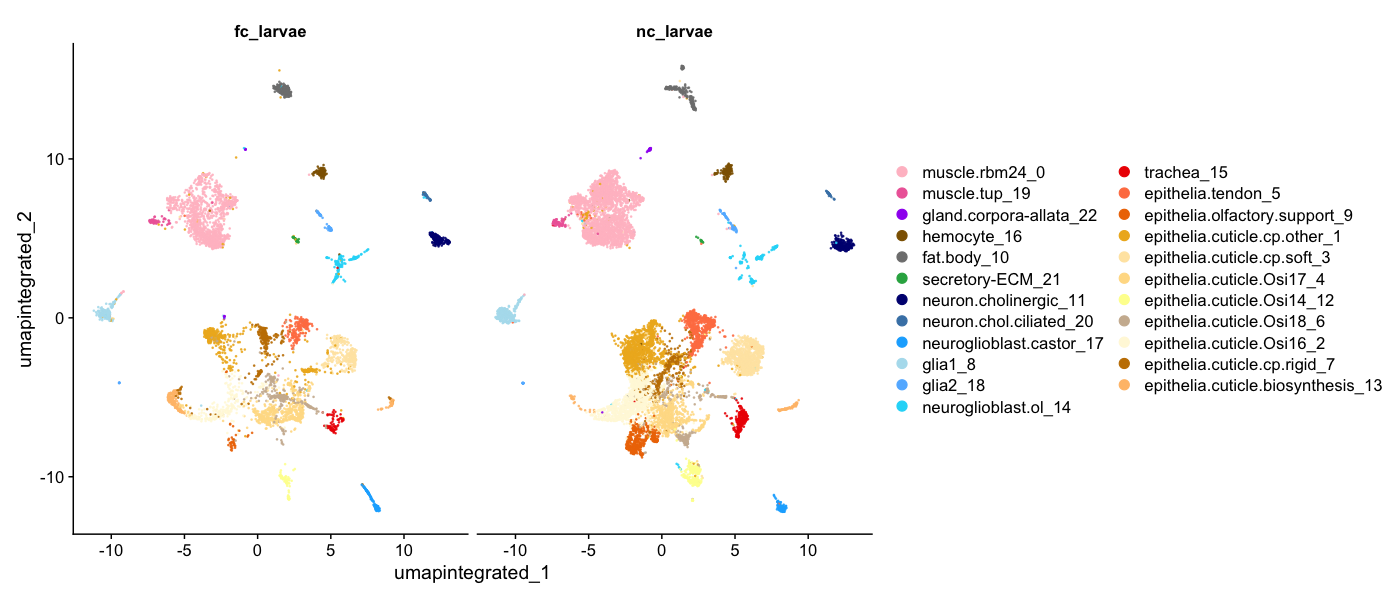

In [26]:
# pdf(file = "Split_UMAP.pdf", width = 14, height = 6) # defaults to 7 x 7 inches

p = DimPlot(
  objnames,
  reduction = "umap.integrated",
  cols=my_colors_spec, split.by = 'orig.ident',
  shuffle = TRUE, alpha=0.8
)

p
# dev.off()
# p